In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [ ]:
df=pd.read_csv('heart.csv')

In [3]:
df.head(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [5]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [6]:
df.shape

(303, 14)

In [7]:
import seaborn as sns

In [8]:
df['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

C:\Users\durga\AppData\Local\Temp\ipykernel_9752\1816371716.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target',data=df,palette = 'hls')


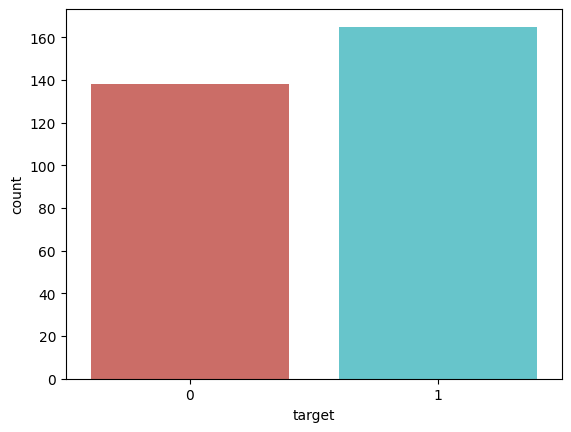

In [9]:
sns.countplot(x='target',data=df,palette = 'hls')
plt.show()

In [10]:
X=pd.DataFrame(df.iloc[:,:-1]) #take all rows , all columns except last
y=pd.DataFrame(df.iloc[:,-1])# take all rows , of only last column

In [11]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [12]:
y.head()

,target
0,1
1,1
2,1
3,1
4,1


In [13]:
X_train, X_test, y_train,y_test=train_test_split(X, y, test_size=0.2,random_state=1)

In [14]:
model = LogisticRegression()
model.fit(X_train,y_train)

c:\Users\durga\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\durga\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

### Use trained logistic regression model to predict target values for test input data and store predictions in y_pred.

In [15]:
y_pred = model.predict(X_test)
model.predict_proba(X_test)

array([[0.99590826, 0.00409174],
       [0.27034998, 0.72965002],
       [0.93542617, 0.06457383],
       [0.99245962, 0.00754038],
       [0.97243125, 0.02756875],
       [0.99557411, 0.00442589],
       [0.99036919, 0.00963081],
       [0.37937037, 0.62062963],
       [0.99489077, 0.00510923],
       [0.01541481, 0.98458519],
       [0.59874613, 0.40125387],
       [0.89856317, 0.10143683],
       [0.23623763, 0.76376237],
       [0.68701061, 0.31298939],
       [0.75461739, 0.24538261],
       [0.06001893, 0.93998107],
       [0.0148142 , 0.9851858 ],
       [0.9827084 , 0.0172916 ],
       [0.47537554, 0.52462446],
       [0.17785921, 0.82214079],
       [0.0228214 , 0.9771786 ],
       [0.97840862, 0.02159138],
       [0.25686537, 0.74313463],
       [0.02659846, 0.97340154],
       [0.02100862, 0.97899138],
       [0.24678361, 0.75321639],
       [0.99541535, 0.00458465],
       [0.01675779, 0.98324221],
       [0.13123948, 0.86876052],
       [0.00964206, 0.99035794],
       [0.

In [16]:
print("Accuracy", (model.score(X_test, y_test)))

Accuracy 0.7704918032786885


#### tells difference of original y test values and predicted test values

In [17]:
confusionmatrix = confusion_matrix(y_test, y_pred)

print(confusionmatrix)

[[20 10]
 [ 4 27]]


In [18]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

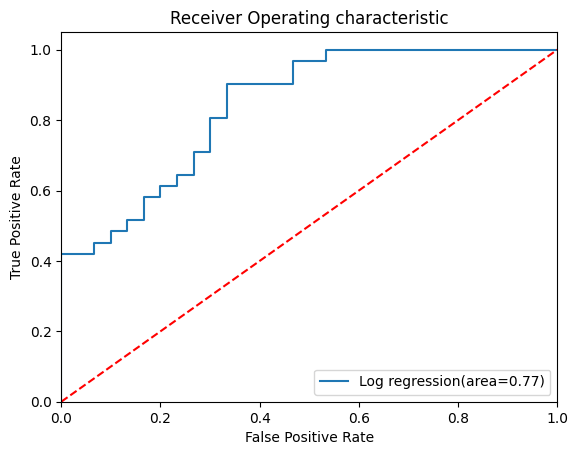

In [19]:
logit_roc_auc = roc_auc_score(y_test, model.predict(X_test))
fpr , tpr, thresholds =roc_curve(y_test, model.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr , tpr , label='Log regression(area=%0.2f)'% logit_roc_auc)
plt.plot([0,1],[0,1],'r--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating characteristic')
plt.legend(loc='lower right')
plt.show()

In [20]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [22]:
import joblib

joblib.dump(model, "heart_model.pkl")

['heart_model.pkl']